<a href="https://colab.research.google.com/github/SriSharanya-617/RAG/blob/main/Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Embeddings + Cosine Similarity + PCA Visualization.

Install dependencies:

In [1]:
!pip install sentence-transformers scikit-learn matplotlib pandas numpy

In [2]:
chunks = [
    "Employees receive 12 casual leaves annually.",
    "Employees receive 15 sick leaves annually.",
    "Employees may work from home twice per week.",
    "Travel expenses are reimbursed within 30 days.",
    "All employees are covered under company medical insurance."
]

queries = [
    "How many casual leaves are allowed?",
    "Can employees work remotely?",
    "What is the travel reimbursement process?",
    "Do employees have medical insurance?"
]

Task 1: Load Embedding Model

In [3]:
from sentence_transformers import SentenceTransformer

model_name = "all-MiniLM-L6-v2"

model = SentenceTransformer(model_name)

print("Model Name:", model_name)

sample_embedding = model.encode("sample text")

print("Embedding Dimension:", len(sample_embedding))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model Name: all-MiniLM-L6-v2
Embedding Dimension: 384


Task 2: Generate Chunk Embeddings

In [7]:
chunk_embeddings = model.encode(chunks)

for chunk, emb in zip(chunks, chunk_embeddings):

    print("\nChunk:")
    print(chunk)

    print("Embedding Shape:")
    print(emb.shape)


Chunk:
Employees receive 12 casual leaves annually.
Embedding Shape:
(384,)

Chunk:
Employees receive 15 sick leaves annually.
Embedding Shape:
(384,)

Chunk:
Employees may work from home twice per week.
Embedding Shape:
(384,)

Chunk:
Travel expenses are reimbursed within 30 days.
Embedding Shape:
(384,)

Chunk:
All employees are covered under company medical insurance.
Embedding Shape:
(384,)


Task 3: Analyze Embedding Vectors

In [8]:
for chunk, emb in zip(chunks, chunk_embeddings):

    print("\nChunk:")
    print(chunk)

    print("First 20 Values:")

    print(emb[:20])


Chunk:
Employees receive 12 casual leaves annually.
First 20 Values:
[ 0.0618362   0.01376683  0.03366624  0.0186107   0.03135883  0.06788085
 -0.01135737 -0.01733116 -0.07070484  0.01901567  0.1098766   0.05092814
 -0.0489678  -0.04620624 -0.03665631  0.00247606 -0.06287521  0.00541349
  0.03131726 -0.07714854]

Chunk:
Employees receive 15 sick leaves annually.
First 20 Values:
[ 0.06126364  0.05009587  0.03596273  0.00253234  0.05886815  0.03007157
  0.00620263 -0.00012556 -0.02327204 -0.00199277  0.09904463  0.02734741
 -0.01499912 -0.05225241 -0.05824455  0.00689516 -0.01921887 -0.00015441
 -0.01112937 -0.05974312]

Chunk:
Employees may work from home twice per week.
First 20 Values:
[ 0.00968149 -0.0412338   0.04907801 -0.00404767 -0.02251745  0.02833883
 -0.01207532 -0.07281487 -0.12298819 -0.10405417  0.00648229  0.07671163
 -0.05534682 -0.00503631  0.08058558 -0.04653181 -0.03970739 -0.05092216
  0.05236141 -0.08418249]

Chunk:
Travel expenses are reimbursed within 30 days.
Fi

Task 4: Generate Query Embeddings

In [9]:
query_embeddings = model.encode(queries)

for query, emb in zip(queries, query_embeddings):

    print("\nQuery:")
    print(query)

    print("Embedding Shape:")
    print(emb.shape)


Query:
How many casual leaves are allowed?
Embedding Shape:
(384,)

Query:
Can employees work remotely?
Embedding Shape:
(384,)

Query:
What is the travel reimbursement process?
Embedding Shape:
(384,)

Query:
Do employees have medical insurance?
Embedding Shape:
(384,)


Task 5: Semantic Similarity Analysis

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

for query, q_emb in zip(queries, query_embeddings):

    print("\n")
    print("="*70)
    print("Query:", query)

    for chunk, c_emb in zip(chunks, chunk_embeddings):

        similarity = cosine_similarity(
            [q_emb],
            [c_emb]
        )[0][0]

        print("\nChunk:")
        print(chunk)

        print("Similarity Score:",
              round(similarity,4))



Query: How many casual leaves are allowed?

Chunk:
Employees receive 12 casual leaves annually.
Similarity Score: 0.6552

Chunk:
Employees receive 15 sick leaves annually.
Similarity Score: 0.411

Chunk:
Employees may work from home twice per week.
Similarity Score: 0.1763

Chunk:
Travel expenses are reimbursed within 30 days.
Similarity Score: 0.0493

Chunk:
All employees are covered under company medical insurance.
Similarity Score: 0.0472


Query: Can employees work remotely?

Chunk:
Employees receive 12 casual leaves annually.
Similarity Score: 0.1963

Chunk:
Employees receive 15 sick leaves annually.
Similarity Score: 0.23

Chunk:
Employees may work from home twice per week.
Similarity Score: 0.4834

Chunk:
Travel expenses are reimbursed within 30 days.
Similarity Score: -0.0254

Chunk:
All employees are covered under company medical insurance.
Similarity Score: 0.3006


Query: What is the travel reimbursement process?

Chunk:
Employees receive 12 casual leaves annually.
Similar

Task 6: Identify Most Similar Chunk

In [11]:
import numpy as np

for query, q_emb in zip(queries, query_embeddings):

    similarities = cosine_similarity(
        [q_emb],
        chunk_embeddings
    )[0]

    best_idx = np.argmax(similarities)

    print("\n")
    print("="*70)

    print("Query:")
    print(query)

    print("\nMost Similar Chunk:")
    print(chunks[best_idx])

    print("\nSimilarity Score:")
    print(round(similarities[best_idx],4))



Query:
How many casual leaves are allowed?

Most Similar Chunk:
Employees receive 12 casual leaves annually.

Similarity Score:
0.6552


Query:
Can employees work remotely?

Most Similar Chunk:
Employees may work from home twice per week.

Similarity Score:
0.4834


Query:
What is the travel reimbursement process?

Most Similar Chunk:
Travel expenses are reimbursed within 30 days.

Similarity Score:
0.7255


Query:
Do employees have medical insurance?

Most Similar Chunk:
All employees are covered under company medical insurance.

Similarity Score:
0.803


Task 7: Similar Meaning vs Different Meaning

In [12]:
sentence1 = "Employees receive 12 casual leaves."
sentence2 = "Workers are entitled to 12 annual leaves."

sentence3 = "Employees receive 12 casual leaves."
sentence4 = "Travel expenses are reimbursed within 30 days."

In [13]:
emb1 = model.encode(sentence1)
emb2 = model.encode(sentence2)

emb3 = model.encode(sentence3)
emb4 = model.encode(sentence4)

In [14]:
sim_pair1 = cosine_similarity(
    [emb1],
    [emb2]
)[0][0]

sim_pair2 = cosine_similarity(
    [emb3],
    [emb4]
)[0][0]

print("Pair 1 Similarity:", round(sim_pair1,4))
print("Pair 2 Similarity:", round(sim_pair2,4))

Pair 1 Similarity: 0.771
Pair 2 Similarity: 0.175


Task 8: Embedding Visualization Using PCA

In [16]:
import numpy as np

all_texts = chunks + queries

all_embeddings = model.encode(all_texts)

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

reduced = pca.fit_transform(all_embeddings)

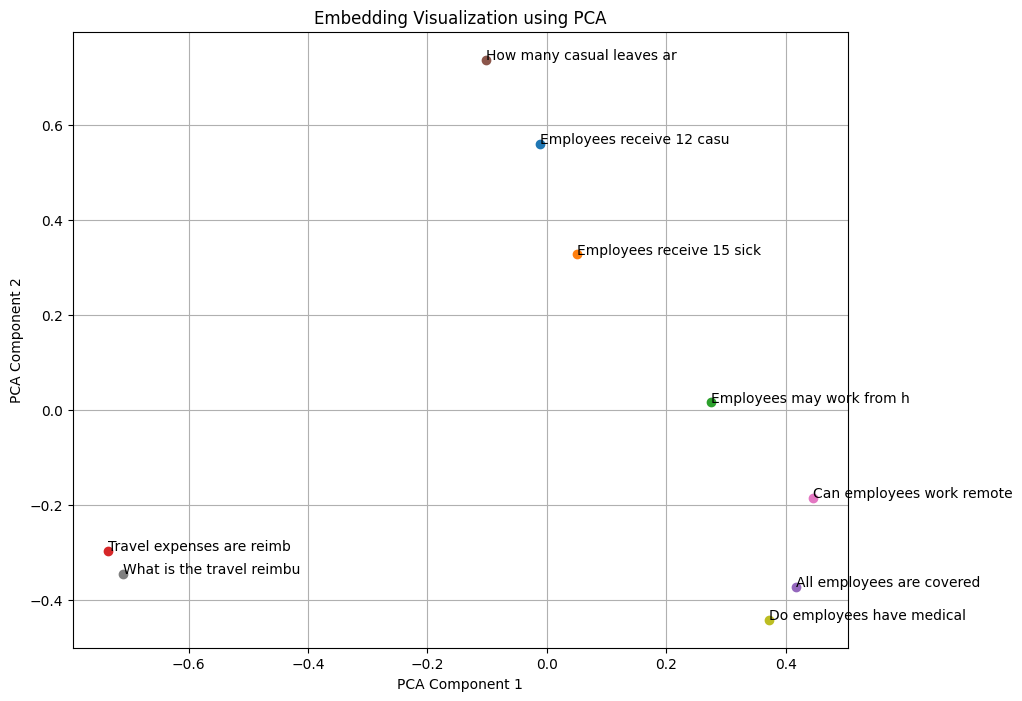

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

for i, text in enumerate(all_texts):

    x = reduced[i,0]
    y = reduced[i,1]

    plt.scatter(x,y)

    plt.annotate(
        text[:25],
        (x,y)
    )

plt.title(
    "Embedding Visualization using PCA"
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.grid(True)

plt.show()